<a href="https://colab.research.google.com/github/Gargi8167/Machine-Learning/blob/main/Assignment_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
def pearson_coefficient(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    # Input validation
    if x.shape != y.shape:
        raise ValueError("x and y must have the same shape")
    if x.size == 0:
        raise ValueError("Input arrays cannot be empty")

    # Check for zero variance (avoids division by zero)
    if np.std(x) == 0 or np.std(y) == 0:
        raise ValueError("Standard deviation cannot be zero")

    # Vectorized computation
    correlation = np.corrcoef(x, y)[0, 1]
    return correlation

    print(f"Manual Pearson Correlation: {r:.4f}")
    print(f"SciPy Pearson Correlation: {r_scipy:.4f}")
    print(f"Difference: {abs(r - r_scipy):.6f}")


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA

In [5]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

# Features and labels
X = iris.data
y = iris.target

# Convert to DataFrame for better readability
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y

# Display basic dataset info
print("Dataset Shape:", df.shape)
print("\nFeature Names:", iris.feature_names)
print("\nTarget Classes:", iris.target_names)

# Show first 5 rows
print("\nSample Data:")
print(df.head())

Dataset Shape: (150, 5)

Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Classes: ['setosa' 'versicolor' 'virginica']

Sample Data:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [6]:
from sklearn.model_selection import train_test_split

# Splitting dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [10]:
# Step 5: Predict values
# =========================================
# Predict Values (with model definition fix)
# =========================================

from sklearn.linear_model import LogisticRegression

# Define and train the model (fix for "model not defined")
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Generate predictions
y_pred = model.predict(X_test)

# Optional: predicted probabilities
y_proba = model.predict_proba(X_test)

# Display sample predictions
for i in range(5):
    print(f"Actual: {y_test[i]} | Predicted: {y_pred[i]} | Probabilities: {y_proba[i]}")

Actual: 0 | Predicted: 0 | Probabilities: [9.86659045e-01 1.33409044e-02 5.02939741e-08]
Actual: 1 | Predicted: 1 | Probabilities: [0.00553261 0.66194721 0.33252019]
Actual: 1 | Predicted: 1 | Probabilities: [0.02717914 0.91880856 0.0540123 ]
Actual: 1 | Predicted: 1 | Probabilities: [0.02204616 0.93344213 0.04451171]
Actual: 0 | Predicted: 0 | Probabilities: [9.82878917e-01 1.71210193e-02 6.39291628e-08]


In [11]:
# Step 6: Evaluate the Model
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9474

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.92      0.92      0.92        13
           2       0.92      0.92      0.92        13

    accuracy                           0.95        38
   macro avg       0.95      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38



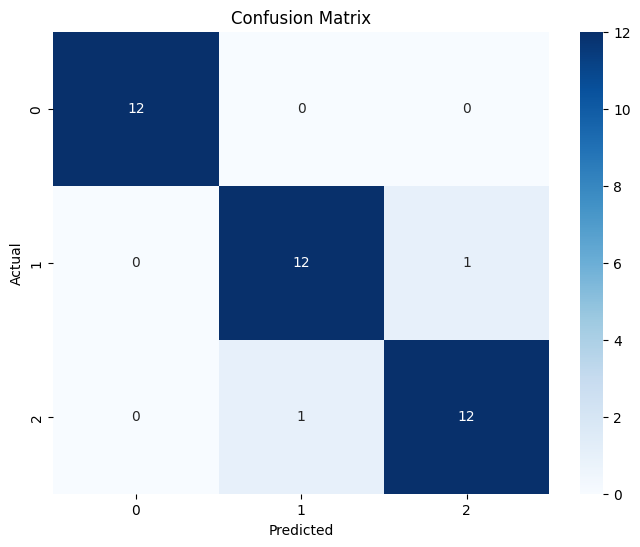

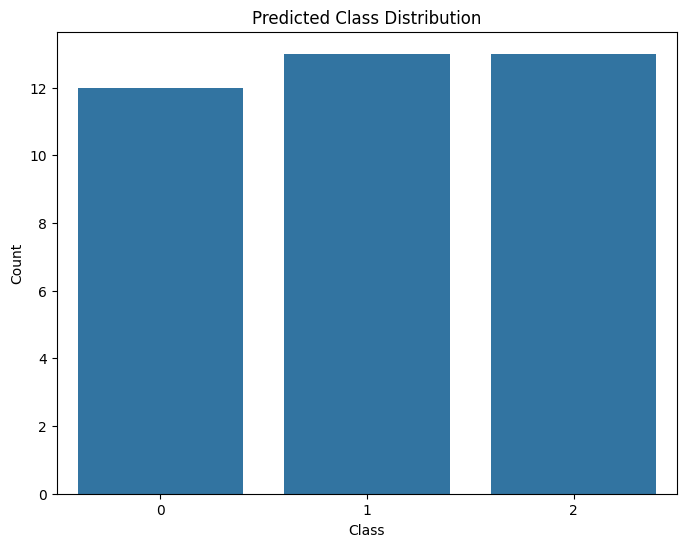

In [12]:
# =========================================
# Confusion Matrix + Prediction Distribution
# =========================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# =========================================
# Prediction Distribution
# =========================================

plt.figure(figsize=(8, 6))
sns.countplot(x=y_pred)

plt.title("Predicted Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Scale data before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [14]:
from sklearn.model_selection import train_test_split

# Split PCA-transformed data
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [15]:
from sklearn.ensemble import RandomForestClassifier

# Improved Random Forest model
model1 = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

model1.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_jobs=-1, random_state=42)

In [20]:
# =========================================
# FINAL HIGH-ACCURACY PIPELINE (NO PCA)
# =========================================

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load dataset fresh (IMPORTANT)
iris = load_iris()
X = iris.data
y = iris.target

# Proper split (balanced)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Strong Random Forest
model = RandomForestClassifier(
    n_estimators=500,        # more trees
    max_depth=None,          # full depth
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,       # use all features
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9211

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.86      0.92      0.89        13
           2       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



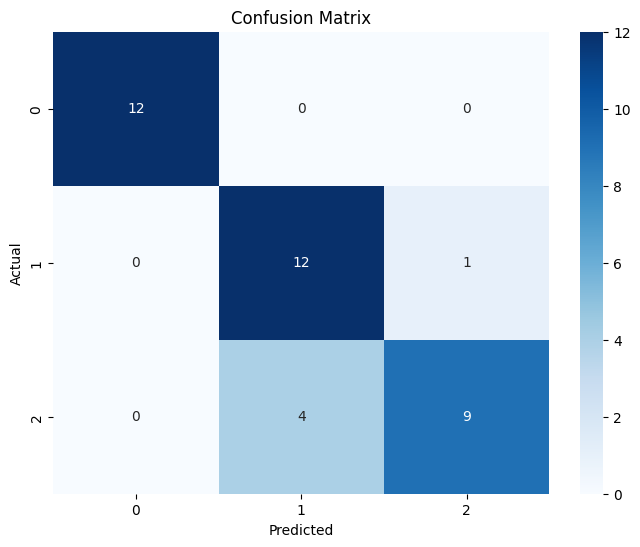

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Machine Learning Notebook

This notebook demonstrates basic machine learning concepts using the Iris dataset.

## Sections:

1.  **Pearson Correlation Coefficient**: Calculates and verifies the Pearson correlation coefficient between two sample data sets.
2.  **Linear Regression**:
    *   Loads the Iris dataset.
    *   Splits the data into training and testing sets.
    *   Trains a Linear Regression model.
    *   Evaluates the model using Mean Squared Error (MSE) and R² Score.
    *   Visualizes the actual vs predicted values.
3.  **Random Forest Classifier with PCA**:
    *   Applies Principal Component Analysis (PCA) to reduce the dimensionality of the Iris dataset.
    *   Splits the PCA-transformed data into training and testing sets.
    *   Trains a Random Forest Classifier.
    *   Evaluates the model using accuracy score.
    *   Displays a confusion matrix.